# 13 - Full Pipeline Test
Detection -> crop -> contrast normalize -> Recognition, end to end.

In [124]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageOps
import torchvision.transforms as T
from scipy import ndimage
import random
import glob
import os
import string
import matplotlib.pyplot as plt

from src.recognition import OCRModel, load_vocab, build_transform, generate


In [125]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


## Detection model classes
(Not yet refactored into `src/detection/` - pasted here for now.)

In [126]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.block1 = ConvBlock(in_channels, base_channels)
        self.block2 = ConvBlock(base_channels, base_channels * 2)
        self.block3 = ConvBlock(base_channels * 2, base_channels * 4)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        s1 = self.block1(x)
        x = self.pool(s1)
        s2 = self.block2(x)
        x = self.pool(s2)
        s3 = self.block3(x)
        x = self.pool(s3)
        return x, (s1, s2, s3)


class Decoder(nn.Module):
    def __init__(self, base_channels=32):
        super().__init__()
        self.up3 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_channels * 4 + base_channels * 4, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels * 2 + base_channels * 2, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels + base_channels, base_channels)
        self.out_conv = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x, skips):
        s1, s2, s3 = skips
        x = self.up3(x)
        x = torch.cat([x, s3], dim=1)
        x = self.dec3(x)
        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.dec2(x)
        x = self.up1(x)
        x = torch.cat([x, s1], dim=1)
        x = self.dec1(x)
        return self.out_conv(x)


class DetectionModel(nn.Module):
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.encoder = Encoder(in_channels, base_channels)
        self.decoder = Decoder(base_channels)

    def forward(self, x):
        x, skips = self.encoder(x)
        return self.decoder(x, skips)


## Detection transform + mask-to-boxes

In [127]:
def resize_with_padding(img, target_size, fill=0):
    target_w, target_h = target_size
    w, h = img.size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = img.resize((new_w, new_h), Image.BILINEAR)
    pad_w = max(target_w - new_w, 0)
    pad_h = max(target_h - new_h, 0)
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
    return ImageOps.expand(img_resized, padding, fill=fill)


def build_detection_transform(img_h=256, img_w=256):
    def transform(img):
        img = resize_with_padding(img, (img_w, img_h), fill=0)
        return T.ToTensor()(img)
    return transform


def mask_to_boxes(mask, min_area=10):
    labeled_array, n_components = ndimage.label(mask)
    boxes = []
    for component_id in range(1, n_components + 1):
        ys, xs = np.where(labeled_array == component_id)
        if len(xs) < min_area:
            continue
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()
        boxes.append((x1, y1, x2, y2))
    return boxes


## Box coordinate helpers
Unscale detection-resolution boxes back to the original screenshot, with a small margin and rounding (not truncation).

In [128]:
def get_resize_params(orig_size, target_size):
    orig_w, orig_h = orig_size
    target_w, target_h = target_size
    scale = min(target_w / orig_w, target_h / orig_h)
    new_w, new_h = int(orig_w * scale), int(orig_h * scale)
    pad_w = target_w - new_w
    pad_h = target_h - new_h
    return scale, pad_w // 2, pad_h // 2


def unscale_box(box, scale, offset_x, offset_y, margin=4):
    x1, y1, x2, y2 = box
    return (
        max(0, round((x1 - offset_x) / scale) - margin),
        max(0, round((y1 - offset_y) / scale) - margin),
        round((x2 - offset_x) / scale) + margin,
        round((y2 - offset_y) / scale) + margin,
    )


## Crop preparation for recognition

**Root cause found:** detection's synthetic backgrounds are drawn from a random luminance range
(`random_theme`), so they are rarely pure white (255) the way recognition's training data
always was. This compresses the crop's pixel range well inside what recognition expects,
causing predictions to collapse into repetitive garbage regardless of font, size, or polarity.

Contrast normalization stretches each crop's actual min/max back out to the full 0-255 range
before recognition sees it, matching the distribution recognition was trained on.

In [129]:
def normalize_contrast_and_polarity(img):
    arr = np.array(img.convert('L')).astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6) * 255

    # after stretching, decide polarity by checking which value is more common:
    # background should be the majority of pixels — if the majority is dark, invert
    if np.median(arr) < 127:
        arr = 255 - arr

    return Image.fromarray(arr.astype(np.uint8))

def prepare_crop_for_recognition(crop, min_aspect_ratio=2.0, pad_color=(255, 255, 255)):
    w, h = crop.size
    if w / h < min_aspect_ratio:
        target_w = int(h * min_aspect_ratio)
        pad_total = target_w - w
        new_img = Image.new('RGB', (target_w, h), color=pad_color)
        new_img.paste(crop, (pad_total // 2, 0))
        crop = new_img

    crop = normalize_contrast_and_polarity(crop)
    return crop

## Mock screenshot generator
(Pasted from notebook 08.)

In [130]:
FONT_DIR = "C:/Windows/Fonts"
font_paths = glob.glob(os.path.join(FONT_DIR, "*.ttf"))

def font_is_usable(font_path, test_word="hello0129"):
    try:
        font = ImageFont.truetype(font_path, 24)
        dummy = Image.new('L', (10, 10))
        draw = ImageDraw.Draw(dummy)
        bbox = draw.textbbox((0, 0), test_word, font=font)
        return (bbox[2]-bbox[0]) > 20 and (bbox[3]-bbox[1]) > 5
    except Exception:
        return False

bad_fonts = {
    "webdings.ttf", "wingding.ttf", "WINGDNG2.TTF", "WINGDNG3.TTF",
    "symbol.ttf", "BSSYM7.TTF", "MTEXTRA.TTF", "marlett.ttf",
    "REFSPCL.TTF", "seguisym.ttf", "SegoeIcons.ttf", "segmdl2.ttf",
    "l_10646.ttf", "himalaya.ttf", "mmrtext.ttf", "mmrtextb.ttf",
    "ntailu.ttf", "ntailub.ttf", "taile.ttf", "taileb.ttf",
    "msyi.ttf", "javatext.ttf", "phagspa.ttf", "phagspab.ttf",
    "simsunb.ttf", "SimsunExtG.ttf",
    # add any other tofu-box fonts found earlier
}

good_fonts = [f for f in font_paths if font_is_usable(f) and os.path.basename(f) not in bad_fonts]
recognition_fonts = [
    "C:/Windows/Fonts/arial.ttf",
    "C:/Windows/Fonts/calibri.ttf",
    "C:/Windows/Fonts/cour.ttf",
    "C:/Windows/Fonts/times.ttf",
    "C:/Windows/Fonts/verdana.ttf",
    "C:/Windows/Fonts/georgia.ttf",
]
recognition_fonts = [f for f in recognition_fonts if os.path.exists(f)]
print(recognition_fonts)

good_fonts_backup = good_fonts
good_fonts = recognition_fonts
print(len(good_fonts))


['C:/Windows/Fonts/arial.ttf', 'C:/Windows/Fonts/calibri.ttf', 'C:/Windows/Fonts/cour.ttf', 'C:/Windows/Fonts/times.ttf', 'C:/Windows/Fonts/verdana.ttf', 'C:/Windows/Fonts/georgia.ttf']
6


In [131]:
with open("../data/wordlist.txt") as f:
    dictionary_words = [w.strip() for w in f if w.strip().isalpha() and len(w.strip()) >= 2]

def random_string(min_len=2, max_len=10):
    chars = string.ascii_lowercase + string.digits
    length = random.randint(min_len, max_len)
    return ''.join(random.choices(chars, k=length))

def random_sentence(min_words=3, max_words=10):
    n = random.randint(min_words, max_words)
    return [random.choice(dictionary_words) for _ in range(n)]

def get_line_height(font):
    ascent, descent = font.getmetrics()
    return int((ascent + descent) * 1.3)

def get_space_width(font):
    bbox = font.getbbox(" ")
    return max(bbox[2] - bbox[0], 4)

def random_theme(min_contrast=40):
    bg = random.randint(0, 255)
    if bg < 128:
        text = random.randint(min(bg + min_contrast, 255), 255)
    else:
        text = random.randint(0, max(bg - min_contrast, 0))
    return (bg, bg, bg), (text, text, text)


In [132]:
def render_header_block(draw, y, width, text_color, boxes):
    font = ImageFont.truetype(random.choice(good_fonts), random.randint(18, 24))
    line_height = get_line_height(font)
    space = get_space_width(font)
    x = 20
    for word in random_sentence(2, 5):
        bbox = draw.textbbox((x, y), word, font=font)
        draw.text((x, y), word, font=font, fill=text_color)
        boxes.append((x, y, bbox[2], bbox[3], word))
        x = bbox[2] + space
    y += line_height
    draw.line([(20, y), (width - 20, y)], fill=(180, 180, 180), width=1)
    y += 20
    return y, boxes


def render_paragraph_block(draw, y, width, height, text_color, boxes):
    font = ImageFont.truetype(random.choice(good_fonts), random.randint(14, 18))
    line_height = get_line_height(font)
    space = get_space_width(font)
    n_lines = random.randint(3, 8)
    for _ in range(n_lines):
        x = 20
        line_words = random_sentence(4, 9)
        for word in line_words:
            bbox = draw.textbbox((x, y), word, font=font)
            if bbox[2] > width - 20:
                x = 20
                y += line_height
                bbox = draw.textbbox((x, y), word, font=font)
            draw.text((x, y), word, font=font, fill=text_color)
            boxes.append((x, y, bbox[2], bbox[3], word))
            x = bbox[2] + space
        y += line_height
        if y > height - line_height:
            break
    return y, boxes


def render_chat_bubbles(draw, y, width, height, bg_color, text_color, boxes):
    n_bubbles = random.randint(4, 10)
    for _ in range(n_bubbles):
        font = ImageFont.truetype(random.choice(good_fonts), random.randint(14, 18))
        line_height = get_line_height(font)
        space = get_space_width(font)
        words = random_sentence(2, 6)
        sent = random.random() < 0.5
        max_bubble_width = width - 80
        x_cursor = 12
        placed_words = []
        for word in words:
            bbox = font.getbbox(word)
            word_width = bbox[2] - bbox[0]
            if x_cursor + word_width > max_bubble_width - 12:
                break
            placed_words.append(word)
            x_cursor += word_width + space
        actual_text_width = x_cursor - space + 12
        bubble_width = min(actual_text_width, max_bubble_width)
        bubble_x1 = (width - 20 - bubble_width) if sent else 20
        bubble_x2 = bubble_x1 + bubble_width
        bubble_y1 = y
        bubble_y2 = y + line_height + 16
        bubble_fill = tuple(min(255, c + 25) if sum(bg_color) < 400 else max(0, c - 25) for c in bg_color)
        draw.rounded_rectangle([bubble_x1, bubble_y1, bubble_x2, bubble_y2], radius=10, fill=bubble_fill)
        x = bubble_x1 + 12
        text_y = bubble_y1 + 8
        for word in placed_words:
            bbox = draw.textbbox((x, text_y), word, font=font)
            draw.text((x, text_y), word, font=font, fill=text_color)
            boxes.append((x, text_y, bbox[2], bbox[3], word))
            x = bbox[2] + space
        y = bubble_y2 + random.randint(10, 20)
        if y > height - line_height * 2:
            break
    return y, boxes


def render_mock_screenshot(width=800, height=600):
    bg_color, text_color = random_theme()
    img = Image.new('RGB', (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)
    boxes = []
    y = 20
    layout_type = random.choice(['email', 'chat'])
    if layout_type == 'email':
        y, boxes = render_header_block(draw, y, width, text_color, boxes)
        y, boxes = render_paragraph_block(draw, y, width, height, text_color, boxes)
    else:
        y, boxes = render_chat_bubbles(draw, y, width, height, bg_color, text_color, boxes)
    return img, boxes


## Load detection model

In [133]:
det_model = DetectionModel(in_channels=1, base_channels=32).to(device)
det_model.load_state_dict(torch.load("../checkpoints/detection_baseline.pt", map_location=device))
det_model.eval()


DetectionModel(
  (encoder): Encoder(
    (block1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (block2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU

## Load recognition model

In [134]:
stoi, itos = load_vocab("../src/recognition/vocab.json")
vocab_size = len(stoi)

rec_model = OCRModel(
    vocab_size=vocab_size,
    d_model=384,
    n_layers=4,
    n_heads=16,
).to(device)
rec_model.load_state_dict(torch.load("../checkpoints/recognition/archive/model_70k_v2.pt", map_location=device))
rec_model.eval()
rec_model.eval()


OCRModel(
  (encoder): CNNEncoder(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

## Generate a test screenshot

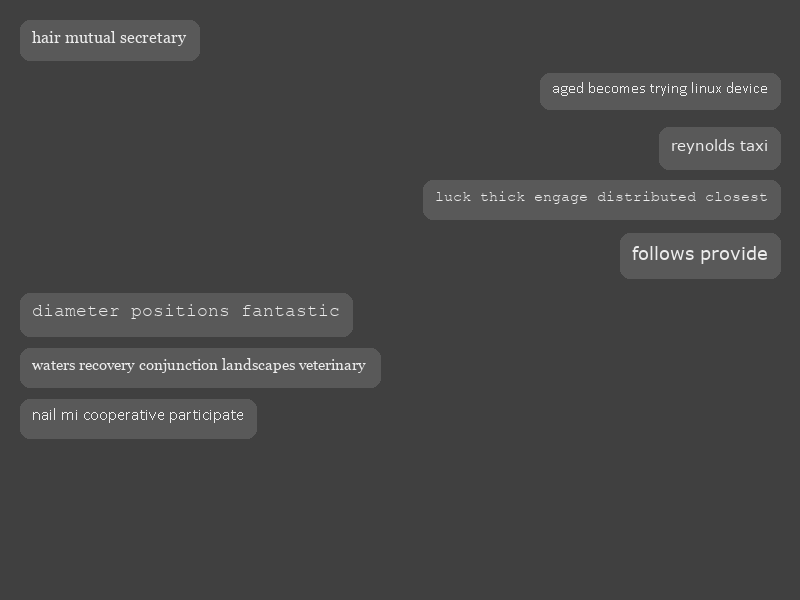

In [135]:
test_img, true_boxes_full = render_mock_screenshot()
test_img


## Run detection

In [136]:
det_transform = build_detection_transform()
img_for_det = test_img.convert('L')
img_tensor = det_transform(img_for_det).unsqueeze(0).to(device)

with torch.no_grad():
    logits = det_model(img_tensor)
    probs = torch.sigmoid(logits)
    pred_mask = (probs[0, 0] > 0.5).float().cpu().numpy()

pred_boxes = mask_to_boxes(pred_mask)
print(f"detected {len(pred_boxes)} boxes")


detected 28 boxes


## Unscale boxes back to original resolution

In [137]:
scale, offset_x, offset_y = get_resize_params(test_img.size, (256, 256))
pred_boxes_full = [unscale_box(b, scale, offset_x, offset_y, margin=3) for b in pred_boxes]


## Crop each detected box, normalize contrast, run recognition

In [138]:
results = []
for box in pred_boxes_full:
    x1, y1, x2, y2 = box
    crop = test_img.crop((x1, y1, x2, y2))
    crop = prepare_crop_for_recognition(crop)   # aspect-ratio pad + contrast normalize

    rec_transform = build_transform(augment=False)
    crop_tensor = rec_transform(crop.convert('RGB'))

    text = generate(rec_model, crop_tensor, itos, device)
    results.append((box, text))

for box, text in results:
    print(box, "->", text)


(28, 25, 62, 44) -> hair
(63, 25, 115, 44) -> mutual
(116, 25, 187, 47) -> secretary
(550, 78, 584, 97) -> aged
(585, 78, 647, 94) -> becomes
(647, 78, 687, 97) -> trying
(688, 78, 722, 94) -> linus
(722, 78, 769, 94) -> dewice
(669, 131, 737, 156) -> reynolds
(738, 131, 769, 153) -> taxi
(431, 185, 472, 203) -> luck
(478, 185, 525, 203) -> thick
(531, 185, 587, 206) -> engage
(594, 185, 697, 203) -> distributed
(703, 185, 769, 203) -> closse
(628, 238, 697, 262) -> follows
(697, 238, 769, 265) -> provide
(28, 297, 122, 319) -> diameter
(128, 297, 231, 322) -> positions
(238, 297, 341, 319) -> fantastic
(28, 353, 75, 372) -> waters
(75, 353, 219, 375) -> reconjunction
(219, 353, 297, 375) -> landscapes
(297, 353, 369, 375) -> veterinary
(28, 403, 59, 422) -> nail
(59, 403, 81, 422) -> mi
(81, 403, 165, 425) -> cooperative
(166, 403, 244, 425) -> participate


## Visualize final result

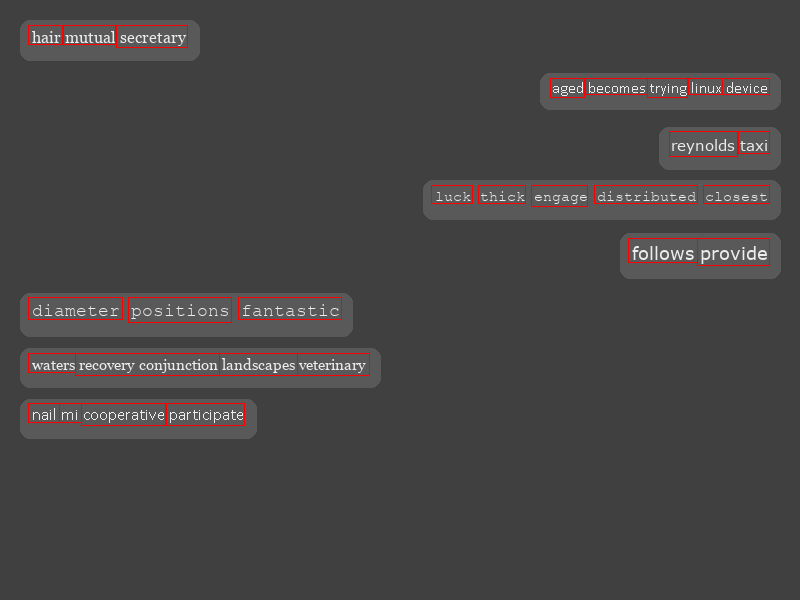

In [139]:
img_check = test_img.copy()
draw = ImageDraw.Draw(img_check)
for box, text in results:
    draw.rectangle(box, outline=(255, 0, 0), width=1)
img_check
